In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro, kstest, probplot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot


### Carga dos dados

In [4]:
df_pontuacao = pd.read_csv('./dataset/pontuacao_teste.csv')
df_pontuacao.head()

,horas_estudo,pontuacao_teste
0,1.1,30
1,2.0,55
2,2.5,60
3,3.6,75
4,4.2,85


In [5]:
df_pontuacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   horas_estudo     101 non-null    float64
 1   pontuacao_teste  101 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


### Análise Exploratória dos Dados

In [6]:
# Medidas estatísticas das variáveis
df_pontuacao.describe()

,horas_estudo,pontuacao_teste
count,101.000000,101.000000
mean,28.604950,455.000000
std,14.116128,221.385411
min,1.100000,30.000000
25%,16.500000,270.000000
50%,30.900000,465.000000
75%,41.800000,655.000000
max,46.900000,800.000000


<Axes: xlabel='horas_estudo', ylabel='pontuacao_teste'>

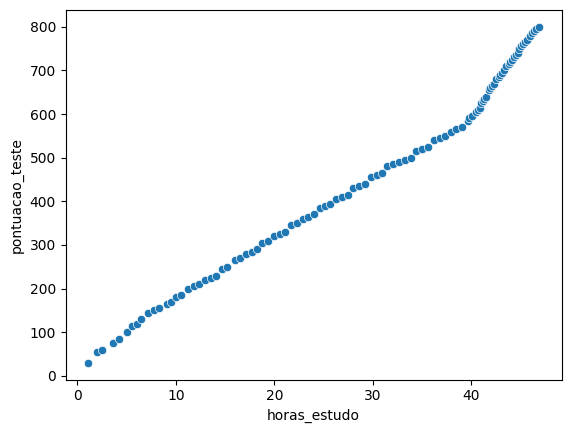

In [7]:
# plot de dispersão: como essas variáveis se relacionam no plano cartesiano
# X = horas_estudo
# Y = pontuacao_teste

sns.scatterplot(data=df_pontuacao, x='horas_estudo', y='pontuacao_teste')

<Axes: ylabel='horas_estudo'>

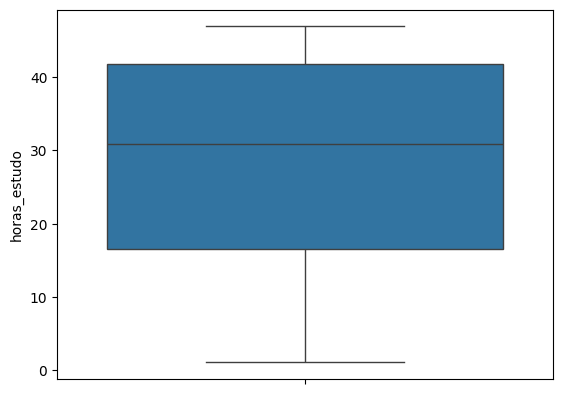

In [8]:
# Verificar se temos outliers através do boxplt

# Para as horas de estudo
sns.boxplot(df_pontuacao, y='horas_estudo')

<Axes: ylabel='pontuacao_teste'>

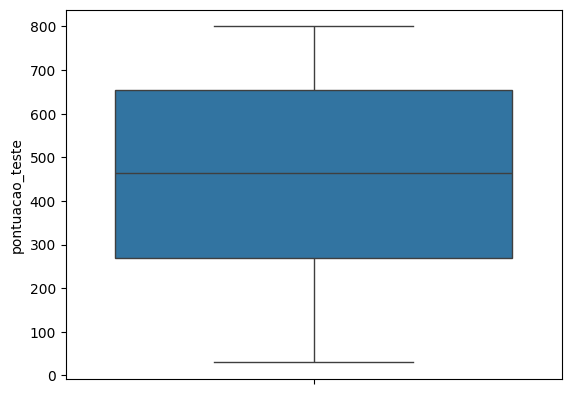

In [9]:
# Para a variável pontuação
sns.boxplot(df_pontuacao, y='pontuacao_teste')

<Axes: >

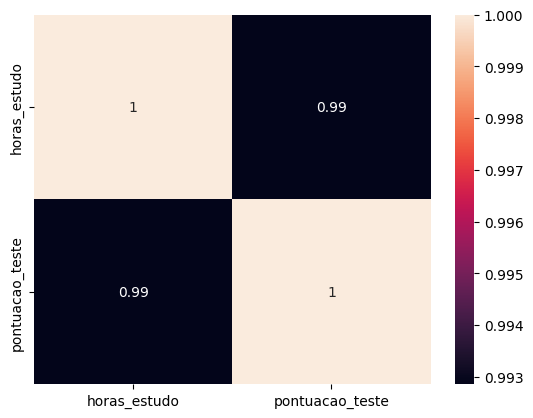

In [10]:
# Verificar correlação - Pearson (correlações lineares)
sns.heatmap(df_pontuacao.corr('pearson'), annot = True)

<Axes: >

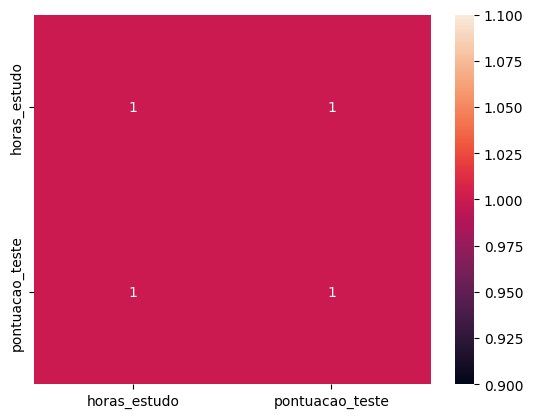

In [11]:
# Verificar correlação - Spearman (correlações não lineares)
sns.heatmap(df_pontuacao.corr('spearman'), annot = True)

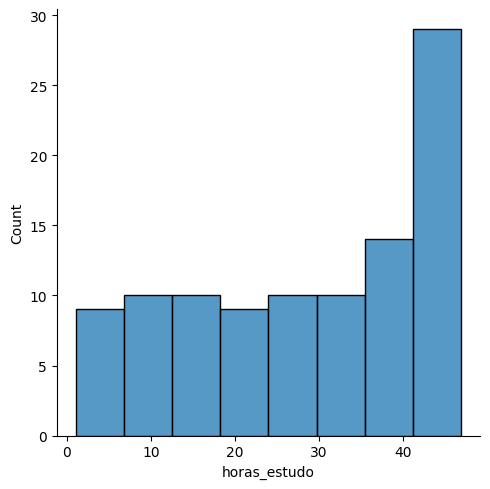

In [12]:
# Histograma das variáveis
sns.displot(df_pontuacao, x='horas_estudo')

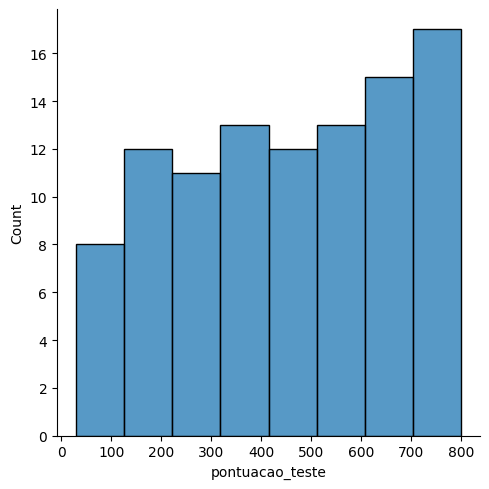

In [13]:
# Histograma das variáveis
sns.displot(df_pontuacao, x='pontuacao_teste')

### Treinar o modelo

In [14]:
# Dividir o dataset entre treino e test
X = df_pontuacao['horas_estudo'].values.reshape(-1, 1)
y = df_pontuacao['pontuacao_teste'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

In [15]:
# Instanciar o modelo de regressão linear
reg_model = LinearRegression()

In [16]:
# Treinar o modelo
reg_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# Printar a interceptação (b0) e o coeficiente angular (b1)
# regressão linear simples: y = mx + b
print("A equação da reta é: y = {:4f}x + {:4f}".format(reg_model.coef_[0][0], reg_model.intercept_[0]))

A equação da reta é: y = 15.642619x + 8.476601


### Validar Modelo - Métricas

In [18]:
# Predição dos valores com base no conjunto de testes
y_pred = reg_model.predict(X_test)

In [19]:
# Comparar a predição (y_pred) com o valor real (y_test)
# Calcular métrica R-Squared ou Coeficiente de Determinação:
# R2 => representa uma proporção na variação na variável dependente que é explicada pela variável independente
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
r2_score(y_pred=y_pred, y_true=y_test)

0.9828400452912442

In [20]:
# Mean absolute error
mean_absolute_error(y_true=y_test, y_pred=y_pred)

22.957470277134615

In [21]:
# Mean squared error
mean_squared_error(y_true=y_test, y_pred=y_pred)

766.9972992416427

In [22]:
# Root mean squared error
root_mean_squared_error(y_true=y_test, y_pred=y_pred)

27.69471608884342

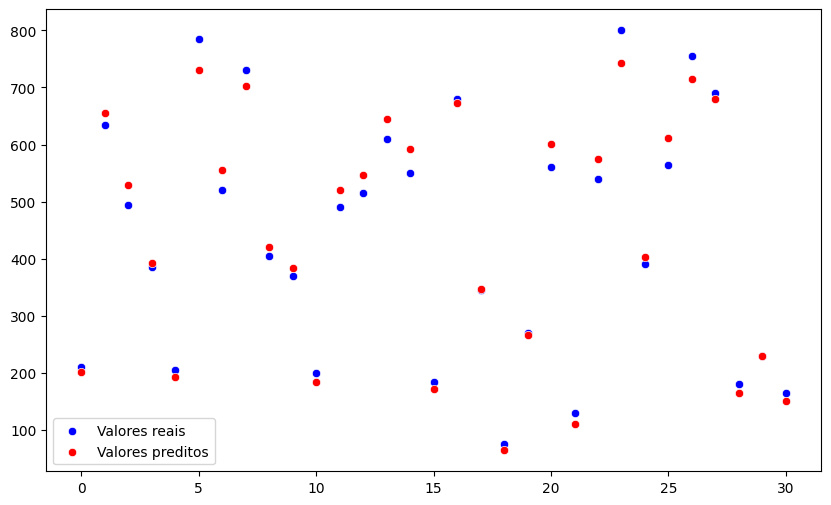

In [23]:
# Análise Gráfica
x_axis =  range(len(y_test))
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_axis, y=y_test.reshape(-1), color='blue', label='Valores reais')
sns.scatterplot(x=x_axis, y=y_pred.reshape(-1), color='red', label='Valores preditos')
plt.legend()
plt.show()

### Análise de resíduos

In [24]:
# Calcular resíduos (erros: diferença do valor real da variável predita (y) e o valor predito => diferença entre y_test e  y_pred)
residuos = y_test - y_pred

In [28]:
# Calcular os resíduos padronizados (standardization)
# Para cada elemento de um conjunto (x - media) / desvio padrao ===> Z SCORE
from scipy.stats import zscore
residuos_std = zscore(residuos)

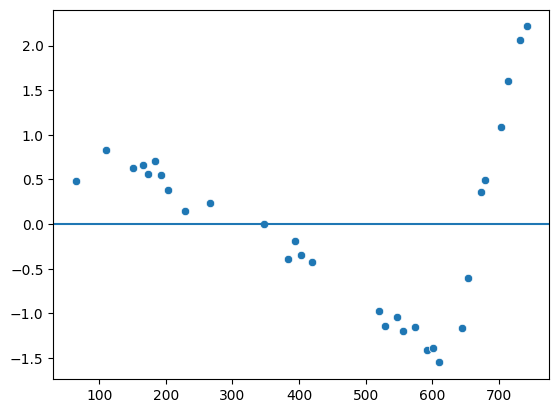

In [29]:
# Verificar linearidade do modelo:
# Se os resíduos estiverem entre -2 e +2 (na escala padrão), isso idica linearidade

# Verificar o homogeneidade das variâncias (Homocedasticidade)
# Valores estiver em torno da reta, temos hocedasticidade, caso contrário
# Se tivermos alguma tendência ou algum padrão (formam um cone, funil, etc), há
# heterocedasticidade
sns.scatterplot(x=y_pred.reshape(-1), y=residuos_std.reshape(-1))
plt.axhline(y=0)

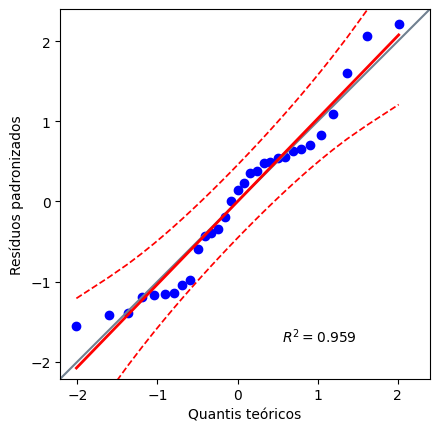

In [30]:
# Checar se os resíduos seguem uma distribuição normal
# QQ (quantile-quantile) plot, que avalia se uma amostra segue uma distribuição normal
import pingouin as pg
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel('Quantis teóricos')
plt.ylabel('Resíduos padronizados')
plt.show()

In [33]:
# Teste de normalidade - Shapiro Wilk
# H0 - Segue distribuição normal
# H1 - Não segue distribuição normal
# se p-valor > 0.05 não rejeita H0, caso contrário rejeitamos
stat_shapiro, p_value_shapiro =  shapiro(residuos.reshape(-1))
print("Estatística do teste: {} e P-Valor: {}".format(stat_shapiro, p_value_shapiro))
print("Rejeita H0? {}".format(p_value_shapiro <= 0.05))

Estatística do teste: 0.9500532226161759 e P-Valor: 0.15663817850304973
Rejeita H0? False


In [34]:
# Teste de normalidade - Kolmogorov-Smirnov
# H0 - Segue distribuição normal
# H1 - Não segue distribuição normal
# se p-valor > 0.05 não rejeita H0, caso contrário rejeitamos
stat_ks, p_value_ks =  kstest(residuos.reshape(-1), 'norm')
print("Estatística do teste: {} e P-Valor: {}".format(stat_ks, p_value_ks))
print("Rejeita H0? {}".format(p_value_ks <= 0.05))

Estatística do teste: 0.48355808450512827 e P-Valor: 3.395368995814077e-07
Rejeita H0? True


### Fazer predições com o modelo

In [35]:
# Se eu estudar 30.4 horas, qual a pontuação que prevista pelo modelo?
reg_model.predict([[30.4]])

array([[484.01220436]])

In [37]:
# Quantas horas eu preciso estudar para tirar 600 pontos (pelo modelo)? 
# y = ax + b
# x = (y - b) / a

(600 - reg_model.intercept_[0]) / reg_model.coef_[0][0]

np.float64(37.81485802710669)

### Salvar modelo para usar futuramente

In [38]:
import joblib
joblib.dump(reg_model, './modelo_regressao.pkl')

['./modelo_regressao.pkl']